# **Assignment 2: Non-Linear Optimization and Optimization Under Uncertainty**


---


**Author**: Lorena Torres Jiménez

**NIA**: 100475834

**DATE**: January 14th, 2026; Master in Big Data Analytics UC3M

This assignment focuses on the study and implementation of optimization methods in both deterministic and uncertain environments. Hence, the main goal is to analyze the behaviour and performance of different optimization techniques when applied to regression and decision-making problems with increasing levels of complexity.

Firstly, regarding topic 3, a high-dimensional linear regression model was considered, in which the number of explanatory variables is large in comparison to the sample size. The model was estimated using Ridge regression, which introduces a regularization term for ensuring numerical stability and uniqueness of the solution. Moreover, the problem was addressed using both analytical and numerical optimization methods, such as gradient-based algorithms, coordinate descent, Newton-type methods and stochastic optimization techniques. Then, a comparative analysis underlined differences in convergence speed, computational efficiency and robustness across methods.

Afterwards, regarding topic 4, an analysis of optimization under uncertainty through a stochastic transportation problem was performed, so that uncertainty was introduced in the selling prices of multiple markets, and the problem was formulated as a two-stage stochastic program. Therefore, first-stage decisions corresponded to production levels, while second-stage ones determined transportation quantities after uncertainty was revealed. The impact of uncertainty was later analyzed by increasing the number of possible scenarios and evaluating key metrics like the Expected Value of Perfect Information (EVPI) and the Value of the Stochastic Solution (VSS).

## **Multiple Linear Regression Model**

---


For this section, a multiple linear regression model was considered, which is described by its generalized form as:

$$Y = X\beta + ϵ$$

For this problem, it is given by:

$$y_i = \sum_{j=0}^K \beta_jx_{ij} + ϵ_i, i = 1,...,n$$

where:
- $y_i$ is the response variable.
- $x_{ij}$ are the explanatory variables.
- $\beta_j$ are the regression coefficients.
- $ϵ_i$ represents random noise drawn from a normal distribution with zero mean.

<br>

However, the synthetic data should be firstly defined:
- $n = 1000$ observations.
- $K \ge 100$ independent variables.
- True regression coefficients $\beta ∈ [-5,5]$, which are randomly generated from a uniform distribution within the interval.

<br>

Moreover, the Ridge regression problem consists on minimizing the given function:
$$min_{β} \frac{1}{n} ∑_{i=1}^n (y_i - x_i^T\beta)^2 + \rho\sum_{j=0}^K \beta_j^2$$

with ρ = 1 being the regularization parameter, and $\beta = (\beta_{0}, \beta_{1}, ..., \beta_{K})^T$. Therefore, it is important to underline that Ridge regression penalizes large coefficients and helps to reduce multicollinearity and overfitting.



Consequently, the objective function has the form of:
$$f(β) = min_{β} \frac{1}{n}(y-X\beta)^T(y-X\beta)+\rho\beta^T\beta$$

where:
- $X \in ℜ^{nx(K+1)}$ denotes the design matrix including the intercept.
- $y \in ℜ^n$ is the vector of observations.
- $\beta \in ℜ^{K+1}$ is the vector of coefficients.

<br>

Note that this formulation highlights the trade-off between data fidelity (least-square term) and regularization (penalty on the magnitude of the coefficients). Hence, the analytical solution is derived from the gradient of the objective function with respect to $β$, so that:


$$∇f(\beta) = -\frac{2}{n}X^T(y-X\beta)+2\rho β$$
<br>
By setting the gradient equal to zero for yielding the first-order optimality condition, it is obtained that:

$$-\frac{2}{n}X^Ty +\frac{2}{n}X^TXβ+2\rho β = 0;$$

$$(X^TX+n\rho I)\beta = X^Ty;$$

$$\hat{\beta} = (X^TX+n\rho I)^{-1}X^Ty$$

With $\hat{\beta}$ being the derived analytical solution and $I$ the identity matrix. However, it is important to note that $np$ is used due to the fact that the error term is divided by $n$. This solution is used as a benchmark to evaluate the accuracy of the numerical optimization methods implemented in the following section.

Therefore, all the previously mentioned equations and parameters were defined computationally.

In [23]:
import numpy as np
import time

np.random.seed(42)

# dimensions
n = 1000        # observations
K = 100         # independent vars
rho = 1.0       # Ridge parameter

# X design matrix (intercept is included in the first column)
X = np.random.randn(n, K)
X = np.c_[np.ones(n), X]
K = K + 1

# Beta real coefficients in [-5, 5]
beta_true = np.random.uniform(-5, 5, size=K)

# noise
epsilon = np.random.normal(0, 1, size=n)

# dependent variable
y = X @ beta_true + epsilon

In [24]:
# analytical solution

def ridge_analytical(X, y, rho):
    n, p = X.shape
    I = np.eye(p)

    # Ridge solution
    beta_hat = np.linalg.inv(X.T @ X + n * rho * I) @ X.T @ y
    return beta_hat

In [25]:
# objective function

def ridge_objective(beta, X, y, rho):
    n = X.shape[0]
    residual = y - X @ beta
    return (1/n) * np.sum(residual**2) + rho * np.sum(beta**2)

In [26]:
# Ridge gradient

def ridge_gradient(beta, X, y, rho):
    n = X.shape[0]
    return (-2/n) * X.T @ (y - X @ beta) + 2 * rho * beta

Furthermore, the Ridge Hessian was defined, which is the matrix containing the second-order partial derivatives of the objective function, and it provides information about the curvature. This function is defined due to the fact that some optimization algorithms, such as Newton's method or Newton-CG, did require it for updating the solution in other sections of the assignment. Consequently, it is given by:

$$∇^2f(\beta) = H = \frac{2}{n}X^TX + 2\rho I$$

In [27]:
# Ridge hessian

def ridge_hessian(X, rho):
    n = X.shape[0]
    p = X.shape[1]
    return (2/n) * (X.T @ X) + 2 * rho * np.eye(p)

Lastly, it is essential to compute the estimation error ($L_2$ norm, also known as the Euclidean distance) between the estimated coefficient and the obtained analytical solution. This parameter shows how well the regularization parameter $\rho$ has balanced the trade-off between bias and variance.
The obtained value for it was 14.71589 approximately, which is relatively large. However, it is expected due to the high dimensionality of the problem and the presence of noise in the data generation process. In addition, Ridge regression does not aim to exactly recover the true coefficients, but to balance bias and variance for improving numerical stability and generalization performance. Thus, the regularization term shrinks the estimated coefficients toward zero, therefore introducing bias that increases the distance from the true parameter vector, even when the overall predictive performance may remain satisfactory.

In [28]:
beta_ridge_analytical = ridge_analytical(X, y, rho)

# estimation error
estimation_error = np.linalg.norm(beta_ridge_analytical - beta_true)

print("Error norm ||beta_hat - beta_true||:", estimation_error)

Error norm ||beta_hat - beta_true||: 14.715892571029848


## **Numerical Estimation Using Different Solvers**

---

The main goal of this section is to solve the Ridge regression problem numerically using the "minimize" function of the Python module "scipy.optimize". Hence, it is desired to estimate the regression coefficients and compare the performance of 4 different optimization algorithms implemented, including BFGS, L-BFGS-B, CG and Newton-CG. Hence, several results will be accounted for this evaluation, such as the number of iterations, function evaluations, gradient and Hessian evaluations (when available), and the total computational time each of them required. This will allow the assessment of the trade-off between convergence speed and computational costs across different optimization methods.


Firstly, the libraries employed in this section were imported.

In [29]:
from scipy.optimize import minimize
import pandas as pd

As explained before, the Ridge regression problem was developed using the minimize function, so that the objective function corresponds to the Ridge loss, which is defined as the sum of the mean squared error (MSE) and an $L_2$ regularization term.

The analytical expressions for the objective function, its gradient and its Hessian, were previously derived, due to the fact that providing exact derivatives allows the optimization algorithms to exploit the structure of the problem, therefore improving both accuracy and computational efficiency.

For this purpose, 4 different methods were accounted:
- BFGS (Broyden-Fletcher-Goldfarb-Shanno): it is a quasi-Newton method that builds an approximation of the Hessian using gradient information only. Even though it does not require the explicit Hessian, it achieves a superlinear convergence close to the optimum.
- CG (Conjugate Gradient): it is a first-order method that iteratively constructs conjugate directions using gradient information. It is an effective method for large, smooth unconstrained problems, although it may require more iterations than second-order methods.
- L-BFGS-B: it is a limited-memory variant of BFGS, which is particularly well-suited for large-scale problems. Hence, it only stores a small number of vectors to approximate to the Hessian, which significantly reduces memory requirements. In this implementation, no explicit boundaries were imposed, but the algorithm benefits from its computational efficiency.
- Newton-CG: it is a second-order method that exploits both gradient and Hessian information, so that instead of explicitly inverting the Hessian, it solves the Newton system using a conjugate gradient procedure. This makes it more suitable for moderately high-dimensional problems.

It is important to note that for the methods that do not require second-order information (BFGS, L-BFGS-B and CG) only the objective function and its gradient were supplied, while for the Newton-CG method, both the gradient and exact Hessian were provided.

Afterwards, performance metrics were collected for each solver, including the number of iterations, the number of function, gradient, and Hessian evaluations, as well as the total computational time. These metrics provided a comprehensive view of the convergence behaviour and computational efficiency across methods for further comparisons.

In [30]:
def run_optimizer(method, X, y, rho, beta_init):
    start_time = time.time()

    result = minimize(
        ridge_objective,
        beta_init,
        args=(X, y, rho),
        method=method,
        jac=ridge_gradient if method in ["BFGS", "CG", "L-BFGS-B", "Newton-CG"] else None,
        hess=(lambda beta, X, y, rho: ridge_hessian(X, rho)) if method == "Newton-CG" else None
    )

    elapsed_time = time.time() - start_time

    stats = {
        "Method": method,
        "Success": result.success,
        "Iterations": result.nit if hasattr(result, "nit") else None,
        "Func evals": result.nfev,
        "Grad evals": result.njev if hasattr(result, "njev") else None,
        "Hess evals": result.nhev if hasattr(result, "nhev") else None,
        "Time (s)": elapsed_time,
        "Final Obj": result.fun
    }

    return result.x, stats

In [31]:
beta_init = np.zeros(K)   # initial point

In [32]:
methods = ["BFGS", "L-BFGS-B", "CG", "Newton-CG"]

results = []
betas = {}

for method in methods:
    beta_hat, stats = run_optimizer(method, X, y, rho, beta_init)
    betas[method] = beta_hat
    results.append(stats)

results_df = pd.DataFrame(results)
print(results_df)


      Method  Success  Iterations  Func evals  Grad evals  Hess evals  \
0       BFGS     True          14          26          26         NaN   
1   L-BFGS-B     True           7           9           9         NaN   
2         CG     True           8          18          18         NaN   
3  Newton-CG     True           8           9           9         8.0   

   Time (s)   Final Obj  
0  0.052171  413.205188  
1  0.016992  413.205188  
2  0.020705  413.205188  
3  0.028115  413.205188  


The results obtained in the table above are highly meaningful and some conclusions can be drawn from them:

All solvers successfully converged to a solution, achieving a nearly identical final objective values, which confirms the strict convexity of the Ridge regression problem, and the correctness of the implementations. However, despite converging to the same optimum, the solvers exhibit notable differences in computational efficiency and numerical accuracy.

The L-BFGS-B method required the smallest number of iterations and function evaluations, 7 and 9 respectively, resulting in a low computational time: 0.016992 seconds. Therefore, this confirms its suitability for high-dimensional problems, in which storing and manipulating full Hessian matrices is computationally expensive. Moreover, the CG method converged in 8 iterations, but it required a higher number of function and gradient evaluations (18). Nevertheless, its total computational time was the second lowest among all methods, 0.020705 seconds, thus reflecting the relatively low cost of each iteration. In addition, the classical BFGS method converged in 14 iterations and required more function and gradient evaluations than L-BFGS-B. As expected, its computational time was higher because of the storage and update of a full Hessian approximation. Lastly, the Newton-CG method also converged in a small number of iterations, 8, and explicitly exploited second-order information. However, its computational time was the highest among the tested solvers, 0.028115 seconds, due to the cost of Hessian evaluations and the inner conjugate-gradient procedure.

In [33]:
for method in methods:
    print(
        method,
        np.linalg.norm(betas[method] - beta_ridge_analytical)
    )

BFGS 5.409297774400895e-06
L-BFGS-B 6.589512742518505e-05
CG 3.6648476966243673e-06
Newton-CG 4.292266111972999e-07


Furthermore, numerical accuracy was assessed with the comparison of estimated coefficient verctors with the analytical solution derived in the first section. Therefore, the Euclidean norm of the estimation error for each solver was computed, obtaining interesting results. Among the tested methods, Newton-CG achieved the highest numerical accuracy (with a difference of 4.29227e-7 approximately), which is consistent with its use of the exact second-order information. Even though L-BFGS-B converged faster, it showed a slightly larger error (6.58951e-5 approximately) due to the approximate nature of its Hessian representation. Also, the other methods, BFGS and CG, provided reliable results, but CG resulted to be more computationally efficient, while BFGS is less scalable in high-dimensional settings.

## **Numerical Estimation Using Different Methods**

---

The main objective of this section is to solve the Ridge regression problem by using optimization algorithms implemented from scratch in Python. Compared to the previous section, no external optimization solvers were implemented in this case, so that the goal is to analyze the convergence behaviour and performance of first and second-order methods.

The first algorithm implemented was the standard Gradient Descent method, which iteratively updates the parameter vector $\beta$ by moving in the direction of the negative gradient of the objective function (opposite direction of the gradient of the objective function), so that:

$$\beta^{(k+1)} = \beta^{(k)} - \alpha ∇f(\beta^{(k)})$$

Where α > 0 denotes the step size (also denoted as learning rate) and ∇(f) = β is the gradient of the Ridge objective. Hence, this is applied for solving the Ridge regression problem.

Recalling the previously defined equations, for the Ridge regression objective, the gradient is given by:

$$\nabla f(\beta) = -\frac{2}{n}X^T(y-X\beta)+2\rho\beta$$

Hence, the algotithm starts from an initial guess $\beta^{(0)}$ and iterates until a stopping criterion is met, so that when the norm of the gradient falls below a predefined tolerance, in this case it was set at 1e-6. Another option would be when the maximum number of iterations is reached, in this case 5000, but this technique is not implemented for this problem. Also, since the Ridge objective is smooth and strongly convex, Gradient Descent is ensured to converge to the unique global minimum for enoughly small step sizes. Nevertheless, its convergence rate is linear and it highly depends on the conditioning of the Hessian matrix ($κ = \frac{λ_{max}(H)}{\lambda_{min}(H)}$). Hence, if κ has a low value, the gradient descent moves directly toward the center, while if it has a large value, the gradient descent zig-zags back and forth while making very slow progress. Then, Gradient Descent requires a relatively large number of iterations to converge, despite the iterations are computationally inexpensive.

Consequently, the algorithm was developed and the obtained results were printed, but discussed at the end of the section with the Newton method's results.

In [34]:
# Gradient Descent

def gradient_descent(
    X, y, rho,
    beta_init,
    step_size=0.01,
    tol=1e-6,
    max_iter=5000
):
    beta = beta_init.copy()
    history = []
    start_time = time.time()

    for k in range(max_iter):
        grad = ridge_gradient(beta, X, y, rho)
        beta_new = beta - step_size * grad

        history.append(np.linalg.norm(grad))

        if np.linalg.norm(beta_new - beta) < tol:
            break

        beta = beta_new

    elapsed_time = time.time() - start_time

    return beta, {
        "Iterations": k + 1,
        "Time (s)": elapsed_time,
        "Final grad norm": history[-1]
    }

In [35]:
beta_gd, stats_gd = gradient_descent(
    X, y, rho,
    beta_init,
    step_size=0.01
)

print(stats_gd)
print("Error - analytical:",
      np.linalg.norm(beta_gd - beta_ridge_analytical))

{'Iterations': 366, 'Time (s)': 0.07171964645385742, 'Final grad norm': np.float64(9.841073715282541e-05)}
Error - analytical: 3.051361152704096e-05


The second implemented algorithm was the Newton method, which incorporates second-order information by using the Hessian matrix to scale the gradient, so that it is sought to find where the gradient of the objective function equals to 0 iteratively, and the update rule is given by:

$$\beta^{(k+1)} = \beta^{(k)} - H^{-1}\nabla f(\beta^{(k)})$$

Where $H = \nabla^2 f(\beta)$ is the Hessian of the objective function. This is repeated until the stopping criterion is met, so that the norm falls below a predefined tolerance. Moreover, again recalling the previously defined equations, for the Ridge regression, the Hessian is a constant given by:

$$H = \frac{2}{n}X^TX + 2\rho I$$

Then, since the Hessian does not depend on β, it can be computed once at the beginning of the algorithm and then reused at every iteration.

It is important to highlight that this method exhibits quadratic convergence in the neighbourhood of the optimum, so once the iterates are enoughly close to the solution, the error decreases exponentially fast. Also, note that the presence of the Ridge penalty ensures that the Hessian is positive definite, guaranteeing that the Newton direction is always a descent direction. Lastly, the predefined tolerance for this method was 1e-8, and the maximum number of iterations was 50.

Again, the algorithm was developed and the results were printed below, which were later discussed.

In [36]:
# Newton method

def newton_method(
    X, y, rho,
    beta_init,
    tol=1e-8,
    max_iter=50
):
    beta = beta_init.copy()
    H = ridge_hessian(X, rho)
    H_inv = np.linalg.inv(H)

    start_time = time.time()

    for k in range(max_iter):
        grad = ridge_gradient(beta, X, y, rho)
        beta_new = beta - H_inv @ grad

        if np.linalg.norm(beta_new - beta) < tol:
            break

        beta = beta_new

    elapsed_time = time.time() - start_time

    return beta, {
        "Iterations": k + 1,
        "Time (s)": elapsed_time,
        "Final grad norm": np.linalg.norm(grad)
    }

In [37]:
beta_newton, stats_newton = newton_method(
    X, y, rho,
    beta_init
)

print(stats_newton)
print("Error - analytical:",
      np.linalg.norm(beta_newton - beta_ridge_analytical))

{'Iterations': 2, 'Time (s)': 0.0009450912475585938, 'Final grad norm': np.float64(3.15068793514982e-14)}
Error - analytical: 9.141648441722564e-15


In [38]:
print(pd.DataFrame([
    {"Method": "Gradient Descent", **stats_gd},
    {"Method": "Newton", **stats_newton}
]))

             Method  Iterations  Time (s)  Final grad norm
0  Gradient Descent         366  0.071720     9.841074e-05
1            Newton           2  0.000945     3.150688e-14


By insight of the table above, some conclusions may be drawn about the results:
- Both methods successfully converged to the optimal solution, as indicated by the considerably small norm of the final gradient. Nevertheless, their convergence behaviour differs significantly.
- The Gradient Descent method required 366 iterations to meet the stopping criterion, an even though each iteration is computationally inexpensive, the linear convergence rate of the method results in a relatively large number of iterations. Moreover, the final gradient norm is approximately 9.84107e-5, which shows a satisfactory convergence within the specified tolerance.
- The Newton's method converged in only 2 iterations, achieving a final gradient norm considerably small (3.15069e-14 approximately). The extremely fast convergence is due to the use of the exact second-order information and because of the Ridge regression objective function being quadratic. For quadratic objectives, Newton's method converges in at most one iteration in exact arithmetic, so the small number of iterations observed for this method is due to the numerical precision and stopping criteria.
- Regarding the total computational time, the Newton's method, which should have been higher due to costly Hessian-based updates, was similarly fast compared to Gradient Descent. Henceforth, this underlines the advantage of second-order methods when the Hessian is available and inexpensive to compute.

## **Numerical Estimation Using Variants Of The Gradient Method**

---

In this section, the main goal is to implement and analyze two alterntive gradient-based optimization algorithms, the Coordinate Gradient method and the Mini-batch Gradient method. Therefore, both approaches aim to reduce computational cost per iteration and improve scalability in high-dimensional settings.

The first implemented algorithm was the Coordinate Gradient method, also known as the Coordinate Descent method. This one minimizes the the objective function by updating one component of the parameter vector at a time, while maintaining the remaining components fixed. Note that this is done sequentially. Then, at the iteration $k$, the update rule for coordinate $j$ is:

$$\beta^{(k+1)} = \beta^{(k)}-\alpha_j \frac{∂ f(\beta^{(k)})}{∂\beta_j}$$

With $\alpha_j$ denoting the step size associated with coordinate $j$. Moreover, for the Ridge regression objective, the partial derivative with respect to $\beta_j$ can be computed analytically, which allows efficient coordinate-wise updates.

In addition, this method is particularly suitable for high-dimensional problems due to the fact that each iteration updates only a single coordinate, thus reducing per-iteration costs, as well as convergence is guaranteed for convex and differentiable objectives. However, convergence is typically slower than full Gradient Descent, as information from all coordinates is not used simultaneously. Lastly, the tolerance was set at 1e-6 and the maximum number of iterations at 100.

The algorithm was developed and the results were printed below, which were discussed.

In [39]:
# Coordinate Gradient method

def coordinate_gradient_descent(
    X, y, rho,
    beta_init,
    tol=1e-6,
    max_iter=100
):
    n, p = X.shape
    beta = beta_init.copy()

    start_time = time.time()

    for k in range(max_iter):
        beta_old = beta.copy()

        for j in range(p):
            # partial gradient with respect to beta_j
            residual = y - X @ beta
            grad_j = (-2/n) * np.dot(X[:, j], residual) + 2 * rho * beta[j]
            beta[j] -= 0.01 * grad_j   # step fixed per coordinate

        if np.linalg.norm(beta - beta_old) < tol:
            break

    elapsed_time = time.time() - start_time

    return beta, {
        "Iterations": k + 1,
        "Time (s)": elapsed_time
    }

In [40]:
beta_coord, stats_coord = coordinate_gradient_descent(
    X, y, rho,
    beta_init
)

print(stats_coord)
print("Error - analytical:",
      np.linalg.norm(beta_coord - beta_ridge_analytical))

{'Iterations': 100, 'Time (s)': 0.39005064964294434}
Error - analytical: 0.2712857561459784


By insight of the printed results, it can be stated that the algorithm was run for a fixed number of iterations (100), and it took 0.39005 seconds approximately to finish, with an error with respect to the analytical solution of 0.27129 approximately. Hence, even though the algorithm exhibits a stable behaviour, the relatively large error indicates slow convergence. Nevertheless, this outcome is expected, as only once coordinate is updated at each iteration, which clearly limits the amount of curvature information exploited per update. Consequently, many more iterations would be required for achieving an accuracy comparable to the methods deployed on the previous section. Overall, the results illustrate that, while Coordinate Gradient methods are computationally cheap per iteration, their convergence may be slow when high accuracy is required.

The second developed algorithm was the Mini-batch Gradient method, which is a stochastic optimization approach that approximates the full gradient using a randomly selected subset (mini-batch) of the data. Then, the update rule is given by:
<br>
$$\beta^{(k+1)} = \beta^{(k)}-\alpha \nabla f_{B_k}(\beta^{(k)})$$
<br>

Where $B_k$ is the mini-batch used at the iteration $k$. Then, for a mini-batch of size $b$, the approximate gradient is computed only using $b$ observations instead of the entire dataset. Note that the batch size is fixed, but the observations that compose each batch are randomly selected in each epoch by using the "np.random.permutation" function.

Moreover, the choice of the mini-batch size has a significant impact on algorithm performance, so that smaller mini-batches have lower computational costs per iteration, with higher variance in gradient estimates and more iterations required for convergence, while larger mini-batches provide more accurate gradient estimates, with higher per-iteration costs and faster convergence, behaving similarly to full Gradient Descent. Therefore, it may be stated that the batch size controls the trade-off between variance and computational efficiency. Lastly, the tolerance was set at 1e-6 and the maximum number of epochs at 500.

Then, the algorithm was developed and the results obtained were printed and plotted for being discussed.

In [41]:
#Mini-batch Gradient method

def minibatch_gradient_descent(
    X, y, rho,
    beta_init,
    batch_size=50,
    step_size=0.01,
    tol=1e-6,
    max_epochs=500
):
    n, p = X.shape
    beta = beta_init.copy()

    start_time = time.time()

    for epoch in range(max_epochs):
        perm = np.random.permutation(n)
        X_shuff = X[perm]
        y_shuff = y[perm]

        for i in range(0, n, batch_size):
            X_batch = X_shuff[i:i+batch_size]
            y_batch = y_shuff[i:i+batch_size]

            grad = ridge_gradient(beta, X_batch, y_batch, rho)
            beta -= step_size * grad

        if np.linalg.norm(grad) < tol:
            break

    elapsed_time = time.time() - start_time

    return beta, {
        "Epochs": epoch + 1,
        "Time (s)": elapsed_time
    }

In [42]:
batch_sizes = [10, 50, 200, 1000]
mb_results = []

for B in batch_sizes:
    beta_mb, stats_mb = minibatch_gradient_descent(
        X, y, rho,
        beta_init,
        batch_size=B
    )
    error = np.linalg.norm(beta_mb - beta_ridge_analytical)

    mb_results.append({
        "Batch size": B,
        "Epochs": stats_mb["Epochs"],
        "Time (s)": stats_mb["Time (s)"],
        "Error": error
    })

print(pd.DataFrame(mb_results))

   Batch size  Epochs  Time (s)         Error
0          10     500  0.779080  2.694849e+00
1          50     500  0.424620  3.226780e-01
2         200     500  0.209735  4.428946e-02
3        1000     500  0.199886  3.904741e-07


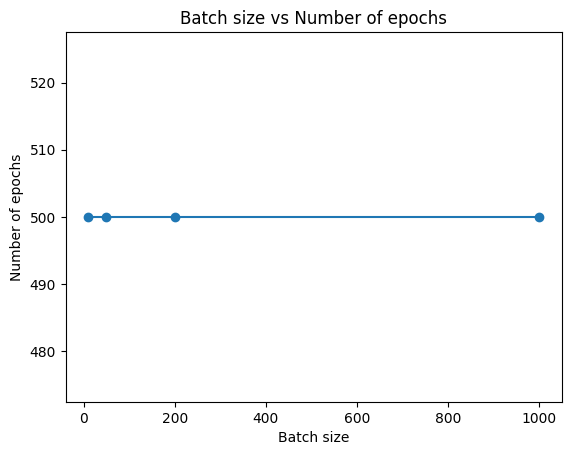

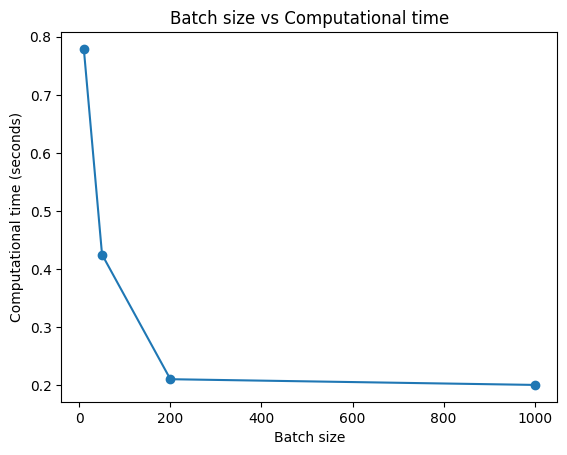

In [43]:
import matplotlib.pyplot as plt

df1 = pd.DataFrame(mb_results)
plt.figure()
plt.plot(df1["Batch size"], df1["Epochs"], marker='o')
plt.xlabel("Batch size")
plt.ylabel("Number of epochs")
plt.title("Batch size vs Number of epochs")
plt.show()

plt.figure()
plt.plot(df1["Batch size"], df1["Time (s)"], marker='o')
plt.xlabel("Batch size")
plt.ylabel("Computational time (seconds)")
plt.title("Batch size vs Computational time")
plt.show()


By insight of the printed table and the graphs above, it may be appreciated that the effect of the mini-batch size clearly influences the convergence accuracy and computational time. With small batch sizes, such as 10, the gradient estimates are very noisy, which lead to poor convergence and large errors despite a high number of fixed epochs. Then, as the batch size increases, the variance of the gradient estimator decreases, thus leading to more stable updates and significantly improved accuracy. Batch sizes of 200, or higher, achieve much lower errors within the same number of epochs, indicating more stable and effective updates. Regarding computational time, intermediate batch sizes provided the best trade-off. Lastly, for a batch size of 1000, corresponding to a full-batch Gradient Descent, the method achieved a very high accuracy (thus the lowest error), which is closely matching the analytical solution, with only a marginal increase in computational time.

Compared to the Coordinate Gradient method, the Mini-batch Gradient approach achieves better accuracy within comparable or even shorter computational times when enoughly large batch sizes are used, therefore highlighting the importance of balancing stochasticity and gradient accuracy.

## **Constrained Optimization Using Penalizations And Projections**

---

For this section, the main goal is to develop a constrained version of the linear regression problem, in which the regression coefficients must satisfy a linear equality constraint, and therefore, estimate them while ensuring strict feasibility with respect to the imposed constraint. Note that such constraints may represent normalization conditions, budget constraints or identification requirements.

Moreover, for addressing the problem, a penalization-based approach was explored and its limitations were discussed, as a projection-based algorithm that enforces the constraint exactly at each iteration was implemented.

Therefore, the problem formulation should be stated for understanding it, so the following constrained optimization problem was considered:
<br>
$$min_{\beta} \frac{1}{n}\sum^n_{i=1}(y_i - \sum^K_{j=0}\beta_jx_{ij})^2$$
<br>

Which is subjected to the linear equality constraint:
<br>
$$\sum^K_{j=1}\beta_j = 1$$
<br>

Note that the intercept term $\beta_0$ is excluded from the constraint, as it does not affect the relative contribution of the explanatory variables. This constraint is used for assessing the effectiveness of the penalization method that will be further introduced. Then, if it is close to 1, it will indicate that the constraint is approximately satisified, therefore confirming that the penalization strategy successfully enforced the constraint in practice.

<br>

Furthermore, the penalization approach was also included, so that a technique for incorporating equality constraints into the objective function via a quadratic penalty term was used for solving this problem. Hence:
<br>
$$min_{\beta} \frac{1}{n} \sum^n_{i=1}(y-X\beta)^2 + \mu \sum^K_{j=1}(\beta_j -1)^2$$
<br>

Where $\mu > 0$ is a penalty parameter. Also, as $\mu → ∞$, the minimizer of the penalized problem converges to the solution of the original constrained problem, thus approaching feasibility with respect to the constraint. Nevertheless, in a finite-precision arithmetic, very large values of $\mu$ lead to severe ill-conditioning of the objective function. Therefore, the previously mentioned equation was computationally developed.



In [44]:
def project_constraint(beta):
    correction = (np.sum(beta[1:]) - 1) / (len(beta) - 1)
    beta_proj = beta.copy()
    beta_proj[1:] -= correction
    return beta_proj

In addition, a projected gradient method was implemented to overcome the limitations of pure penalization. Then, this approach combines gradient-based optimization with an explicit projection onto the feasible set defined by the constraint. At each iteration, the algorithm proceeds in two steps: the gradient step and the projection step. The gradient step is given by:

$$\beta^{(k+1)} = \beta^{(k)} - \alpha \nabla f(\beta^{(k)})$$

While the projection step is given by:

$$\sum^K_{j=1}\beta_j = 1$$

$$\beta_{1:K} ← \beta_{1:K} - \frac{1}{K}(\sum^K_{j=1} \beta_j - 1)$$

Which ensures exact feasibility at every iteration. Note that the coefficients $\beta_1, ..., \beta_K$ are projected onto the affine subspace.

In [45]:
def projected_gradient_descent(
    X, y,
    beta_init,
    step_size=0.01,
    tol=1e-6,
    max_iter=5000
):
    beta = beta_init.copy()
    start_time = time.time()

    for k in range(max_iter):
        grad = (-2 / X.shape[0]) * X.T @ (y - X @ beta)
        beta_new = beta - step_size * grad

        # exact projection
        beta_new = project_constraint(beta_new)

        if np.linalg.norm(beta_new - beta) < tol:
            break

        beta = beta_new

    elapsed_time = time.time() - start_time

    return beta, {
        "Iterations": k + 1,
        "Time (s)": elapsed_time,
        "Constraint violation": np.sum(beta[1:]) - 1
    }

In [46]:
beta_proj, stats_proj = projected_gradient_descent(
    X, y,
    beta_init
)

print(stats_proj)
print("Sum of betas:", np.sum(beta_proj[1:]))

{'Iterations': 1044, 'Time (s)': 0.23729491233825684, 'Constraint violation': np.float64(-1.021405182655144e-14)}
Sum of betas: 0.9999999999999898


Lastly, the results were printed for further discussion of them, so that it may be stated that the projected gradient algorithm converged successfully while strictly enforcing the linear equality constraint. Hence, the extremely small constraint violation (approximately -1.02141e-14) confirms that the equality constraint is satisfied with numerical precision. Moreover, the sum of the regression coefficients, excluding the intercept, is effectively equal to one, as required by the problem formulation. Therefore, despite the relatively large number of iterations required, 1044, the method remained computationally efficient due to the low cost of each iteration. Also, the method guarantees feasibility at every step of the optimization process, in contrast to penalty-based approaches that may, temporarily or permanently, violate the constraint.

Consequently, it may be stated that the final solution approximately satifies the constraint, therefore demonstrating the effectiveness of the penalization method for handling equality constraints. Also, it may be observed that the quality of the approximation depends on the magnitude of the penalty parameter, as larger penalty values lead to better constraint satisfaction, but may deteriorate numerical conditioning and slow down convergence. This underlines the classical trade-off between feasibility and numerical stability when using penalization methods.

## **Formulation Of Optimization Under Uncertainty**

---
From now on, a new problem is addressed. Therefore, the main objective of this section is to define the stated problem in the assignment, so that it can solved numerically and interpreted for further discussion, regarding its results. In this case, optimization under uncertainty is applied to a two-stage extension of the deterministic transportation problem, where the source of uncertainty is the selling prices at each market.

This technique, also known as stochastic optimization, relies on finding the best decision when key parameters are not fixed but they are random variables, so that it is aimed to maximize or minimize an expected objective value or find robust solutions resilitent to uncertainty.




For the formulation of the problem, a concrete set will be used for simplification purposes:
 - $S = \{1, \ldots, s\}$ for scenarios with probability $P_s = \frac{1}{S}$, $\forall s\in S$. Note that all scenarios are assumed to be equiprobable.

<br>

Moreover, the main parameter to be accounted for is:
 - $p_{j}^s$: possible realization of the uncertain prices in the market $j$ under the scenario $s$.

<br>

Afterwards, decision variables should be also defined, so that:
- For the first-stage decision variables: $q_i$ . It refers to the production quantities in a factory $i$, and it must be determined before the realization of uncertainty, so that it is identical for all scenarios (thus independent from the scenario).
- For the second-stage decision variables: $x_{ij}^s$ . It refers to the transport from $i$ to $j$ under the scenario $s$ (dependent from the scenario). Note that they can be adapted to each scenario once prices are revealed.
 <br>

Then, the objective function is based on minimizing the expected total cost over all scenarios, which includes production costs, transportation costs, and revenues from selling the products. Hencefoth, it may be defined as:

<br>

 $$\text{min}_{q_i, x_{ij}^s} \sum_{i} c_i ^Pq_i + E_s[\sum_{i,j}(c_{ij}^T - p_{j}^s)x_{ij}^s]$$

<br>

Lastly, constraints also need to be defined, which must hold for all scenarios $S$:
- Production capacity: $0 \le q_i \le q_i^{max}$, $∀i$
- Market demand (per scenario): $\sum_{i} x_{ij}^s \ge d_j$, $\forall j,s$
- Product transportation coupling (per scenario): $\sum_{i} x_{ij}^s \le q_i$, $\forall i,s$
- Non-negativity: $x_{ij}^s ≥ 0$, $∀i,j,s$

<br>

Therefore, this formulation explicitly separates first-stage and second-stage decisions, and captures the effect of uncertainty through the expected value of the objective function. Consequently, it allows transportation decisions to react optimally to different price realizations while keeping production decisions fixed across scenarios.

## **Pyomo Implementation**

---

The main goal of this section is to implement the mathematical formulation of the proposed problem in Pyomo, and to solve it for an increasing number of equiprobable scenarios, ranging from 1 to 301. Therefore, it is analyzed how the optimal first-stage production decisions and the expected objective function value changes as the number of scenarios increases. Also, the obatined results of the proposed model were printed and plotted for further interpretation and discussion of the results.

Firstly, the libraries employed, Pyomo and the GLPK solver were installed and loaded.

In [47]:
import numpy as np
import pyomo.environ as pyo
import matplotlib.pyplot as plt

In [48]:
!apt-get install -y -qq glpk-utils
!pip install -q pyomo

Selecting previously unselected package libsuitesparseconfig5:amd64.
(Reading database ... 117528 files and directories currently installed.)
Preparing to unpack .../libsuitesparseconfig5_1%3a5.10.1+dfsg-4build1_amd64.deb ...
Unpacking libsuitesparseconfig5:amd64 (1:5.10.1+dfsg-4build1) ...
Selecting previously unselected package libamd2:amd64.
Preparing to unpack .../libamd2_1%3a5.10.1+dfsg-4build1_amd64.deb ...
Unpacking libamd2:amd64 (1:5.10.1+dfsg-4build1) ...
Selecting previously unselected package libcolamd2:amd64.
Preparing to unpack .../libcolamd2_1%3a5.10.1+dfsg-4build1_amd64.deb ...
Unpacking libcolamd2:amd64 (1:5.10.1+dfsg-4build1) ...
Selecting previously unselected package libglpk40:amd64.
Preparing to unpack .../libglpk40_5.0-1_amd64.deb ...
Unpacking libglpk40:amd64 (5.0-1) ...
Selecting previously unselected package glpk-utils.
Preparing to unpack .../glpk-utils_5.0-1_amd64.deb ...
Unpacking glpk-utils (5.0-1) ...
Setting up libsuitesparseconfig5:amd64 (1:5.10.1+dfsg-4b

Then, the data of the problem was defined, including the set of the model and its parameters. However, even though the set was predefined, some other deterministic parameters were included such as the number of factories and markets, costs, demand and capacity.

In [49]:
# deterministic parameters
n = 2  # factories
m = 3  # markets

cT = np.array([[2.5, 1.7, 1.8],[2.5, 1.8, 1.4]]) # transportation costs
cP = np.array([50, 60]) # production costs
d = np.array([325, 300, 275]) # demand per market
qmax = np.array([350, 600]) # maximum capacity per factory

mean_price = np.array([100,120,140]) # mean price
sd_price = np.array([20,25,30]) # standard deviation of the price

Afterwards, different scenarios were generated, so that the uncertainty in market prices was modeled using independent Normal distributions for each market:

$$p_j ∼ Ν(μ_j, σ^2_j)$$
$$\mu = (100, 120,140)$$
$$\sigma = (20,25,30)$$


Where the mean prices and standard deviations correspond to $\mu$ and $σ$ respectively. Hence, for each experiment, a fixed number of scenarios was generated by sampling from these distributions. Note that all scenarios were assumed to be equiprobable, and a fixed random seed was used for ensuring reproducibility.

In [50]:
def generate_price_scenarios(num_scenarios, mean_price, sd_price, seed=42):
    np.random.seed(seed)
    return np.random.normal(loc=mean_price, scale=sd_price, size=(num_scenarios, len(mean_price)))

Then, the stochastic model was implemented in Pyomo as a two-stage stochastic program, so that there were first-stage ($q_i$) and second-stage ($x_{ij}^s$) variables. Also, note that all constraints previously stated were enforced for every scenario, thus ensuring demand satisfaction and consistency between production and transportation decisions.

In [51]:
def solve_stochastic_problem(num_scenarios):
    # generate scenarios
    prices = generate_price_scenarios(num_scenarios, mean_price, sd_price)

    model = pyo.ConcreteModel()

    # sets
    model.I = pyo.RangeSet(n)
    model.J = pyo.RangeSet(m)
    model.S = pyo.RangeSet(num_scenarios)

    # variables
    model.q = pyo.Var(model.I, domain=pyo.NonNegativeReals)
    model.x = pyo.Var(model.I, model.J, model.S, domain=pyo.NonNegativeReals)

    # objective (expected value)
    def obj_rule(m):
        return (1/num_scenarios) * sum(
            sum(cT[i-1,j-1]*m.x[i,j,s] for i in m.I for j in m.J) +
            sum(cP[i-1]*m.q[i] for i in m.I) -
            sum(prices[s-1,j-1]*m.x[i,j,s] for i in m.I for j in m.J)
            for s in m.S
        )
    model.OBJ = pyo.Objective(rule=obj_rule, sense=pyo.minimize)

    # constraints
    def demand_rule(m, j, s):
        return sum(m.x[i,j,s] for i in m.I) >= d[j-1]
    model.demand = pyo.Constraint(model.J, model.S, rule=demand_rule)

    def capacity_rule(m, i):
        return m.q[i] <= qmax[i-1]
    model.capacity = pyo.Constraint(model.I, rule=capacity_rule)

    def production_rule(m, i, s):
        return sum(m.x[i,j,s] for j in m.J) <= m.q[i]
    model.production = pyo.Constraint(model.I, model.S, rule=production_rule)

    # solve
    solver = pyo.SolverFactory('glpk')
    solver.solve(model, tee=False)

    # extract first-stage decisions q_i
    q_values = np.array([pyo.value(model.q[i]) for i in model.I])
    obj_value = pyo.value(model.OBJ)

    return q_values, obj_value

For the purpose of generating a different amount of equiprobable scenarios, the following set was defined:

$$|S| = 1, 11, 21, ..., 301$$

Note that each scenario represents one possible future realization of the three market prices $p^{(s)} = (p_1^{(s)},p_2^{(s)},p_3^{(s)})$. The scenarios were generated using Monte Carlo simulation, so that for each scenario $s$, one sample was drawn from each of the three normal distributions, and as all scenarios were assumed to be equiprobable: $π_s = \frac{1}{S}$. As the number of scenarios $S$ increases, the stochastic model provides a better approximation of the expected value problem, and when $S=1$, the model is equivalent to the deterministic problem using the mean values of the prices.

For each case, the optimal first-stage production quantities $q_i$ and the expected objective function value were recorded.

In [61]:
scenario_counts = list(range(1, 302, 10))  # |S| = 1,11,21,...,301
q_solutions = []
obj_solutions = []
time_results=[]

for s in scenario_counts:
    start_time = time.time()
    q_vals, obj_val = solve_stochastic_problem(s)
    q_solutions.append(q_vals)
    obj_solutions.append(obj_val)
    elapsed = time.time() - start_time
    time_results.append({
        "Scenarios": s,
        "Time (s)": elapsed
    })

Lastly, the results were plotted in different graphs for observing their behaviours, so that:

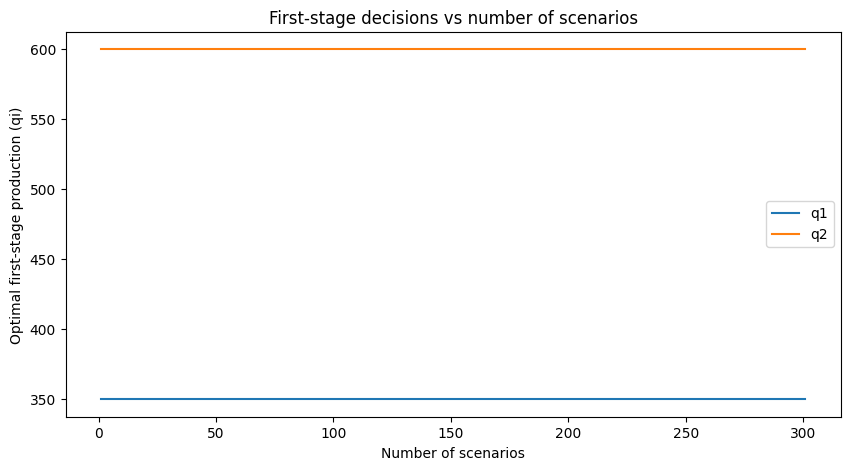

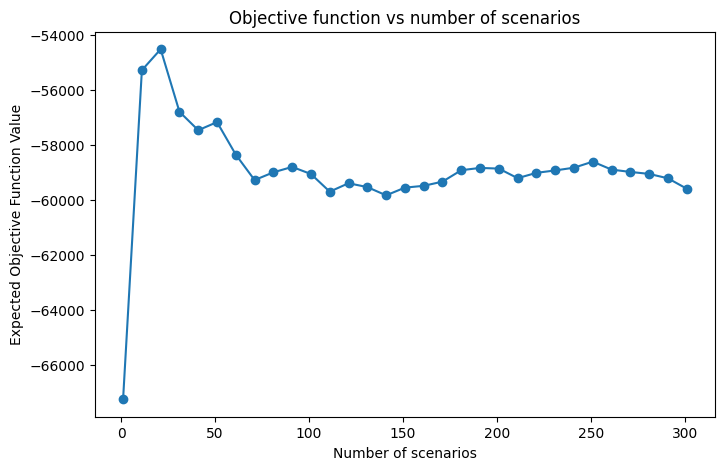

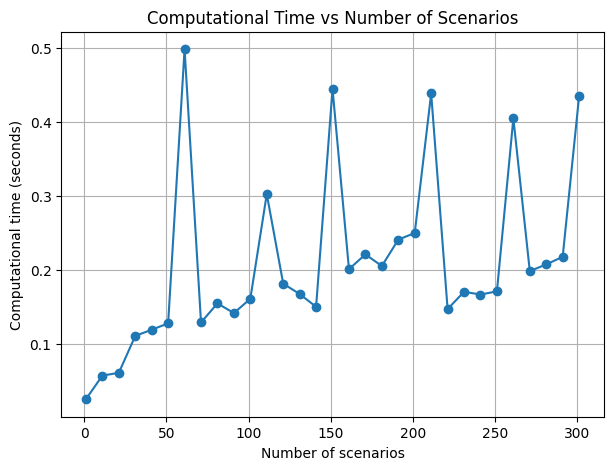

In [62]:
q_solutions = np.array(q_solutions)

plt.figure()
for i in range(n):
    plt.plot(scenario_counts, q_solutions[:,i], label=f'q{i+1}')
plt.xlabel('Number of scenarios')
plt.ylabel('Optimal first-stage production (qi)')
plt.title('First-stage decisions vs number of scenarios')
plt.legend()
plt.show()

plt.figure()
plt.plot(scenario_counts, obj_solutions, marker='o')
plt.xlabel('Number of scenarios')
plt.ylabel('Expected Objective Function Value')
plt.title('Objective function vs number of scenarios')
plt.show()

df_time = pd.DataFrame(time_results)

plt.figure()
plt.plot(df_time["Scenarios"], df_time["Time (s)"], marker="o")
plt.xlabel("Number of scenarios")
plt.ylabel("Computational time (seconds)")
plt.title("Computational Time vs Number of Scenarios")
plt.grid()
plt.show()

By insight of the plots, some conclusions may be drawn:

The first figure shows the evolution of the optimal production levels ($q_1$ and $q_2$) as a function of the number of scenarios. Hence, it indicates that the first-stage production decisions ($q_i$) remained constant across all scenario counts, therefore suggesting that the optimal production levels are primarily determined by deterministic constraints, like demand requirements and production capacity limits, rather than by price uncertainty. Also, it is important to note that the production quantities were chosen to satisfy total demand, while respecting capacity constraints, and these conditions remained unchanged, even though more scenarios were added.

In relation to the second figure, it displayed the expected objective function value as the number of scenarios increases. Unlike the production decisions, the objective function exhibited variations for small numbers of scenarios, while as the number of them increases, the objective value stabilized and converged. This behaviour is expected, following the law of large numbers, since a larger number of scenarios provides a more accurate approximation of the underlying price uncertainty, and adding more scenarios yields disminishing marginal improvements in solution quality. Consequently, this reflects a more accurate approximation of the expected value, in which the increase of the number of scenarios leads to an improvement of the estimation of expected costs and revenues.

Regarding the third figure, it is illustrated how the computational time required to solve the stochastic optimization problem evolves as the number of scenarios $S$ increases. Although the growth is not perfectly smooth, the curve exhibits several pronounced peaks, which is expected in stochastic programming for several reasons. These include that the increasing number of scenarios enlarges the optimization problem, as more second-stage variables $x_{ij}^{(s)}$ and more scenario-dependent constraints are added, what takes more time to solve. Also, the spikes may be due to the fact that the structure of the constraint matrix changes as new scenarios are added, as well as that some instances are numerically harder to solve than others, and that the solver may need different iteration counts depending on the scenario values. Henceforth, the global behaviour indicates that larger scenario sets lead to higher computational effort.

Henceforth, this numerical experiment demonstrated that increasing the number of scenarios improves the stability of the expected objective function while leaving the optimal first-stage decisions unchanged, which emphasizes the importance of scenario selection in stochastic programming.

## **EVPI And VSS For 301 Scenarios**
---

The main goal of this section is to quantify two standard measures used for considering uncertainty explicitly: the Expected Value of Perfect Information (EVPI) and the Value of the Stochastic Solution (VSS). These measures provide information about how much is gained by having access to perfect information, and by solving the stochastic problem instead of a deterministic approximation.

Therefore, in this case, EVPI and VSS were computed for the case with 301 scenarios, and their economic interpretations were further discussed.

Firstly, the EVPI and VSS concepts should be addressed.

In relation to the EVPI, it can be said to be the maximum amount of a decision-maker would be willing to pay to obtain perfect information about the uncertain parameters before making any decisions. Applied to this case, it measures the economic value of knowing future market prices with certainty prior to determining production and transportation decisions. This may be defined as:

$$\text{EVPI} = Z_{WS}-Z_{SS}$$

Where $Z_{WS}$ is the "wait-and-see" solution, obtained by solving the problem separately for each scenario (assuming perfect information) and then taking the expected value, while $Z_{SS}$ is the optimal value of the stochastic solution. Moreover, since the problem is formulated as a minimization problem. Then, a relatively small EVPI indicates that uncertainty has a limited impact on the optimal decisions, as having perfect information about future prices would not significantly improve the expected outcome, whereas a larger EVPI suggests that uncertainty plays an important role and that better information could substantially improve the objective value, therefore reducing costs.

Regarding VSS, it can be said to be the quantification of how much additional expected profit (or reduced expected loss) the company gains by explicitly modeling uncertainty, rather than ignoring it and optimizing using only average prices. Therefore, it compares the optimal value of the stochastic problem with the performance of the deterministic expected value solution when evaluated under uncertainty, and then, it measures the benefit of solving the stochastic problem instead of a deterministic approximation based on expected values, being defined as:

$$\text{VSS} = Z_{EEV}-Z_{SS}$$


Where $Z_{EEV}$ is the expected result of the expected value solution, obtained by several factors. Again, VSS is non-negative, which implies that explicitly accounting for uncertainty leads to better decisions than relying on a deterministic approximation based on expected prices. In this concrete problem, the positive value of VSS would confirm that solving the stochastic optimization problem provides a tangible benefit, therefore remarking the importance of modeling uncertainty explictly.

The proposed code for computing these measures is given below:

In [54]:
# deterministic problem with mean prices
def solve_deterministic_problem(mean_price):
    model = pyo.ConcreteModel()
    model.I = pyo.RangeSet(n)
    model.J = pyo.RangeSet(m)

    model.q = pyo.Var(model.I, domain=pyo.NonNegativeReals)
    model.x = pyo.Var(model.I, model.J, domain=pyo.NonNegativeReals)

    model.OBJ = pyo.Objective(
        expr=sum(cT[i-1,j-1]*model.x[i,j] for i in model.I for j in model.J) +
             sum(cP[i-1]*model.q[i] for i in model.I) -
             sum(mean_price[j-1]*model.x[i,j] for i in model.I for j in model.J),
        sense=pyo.minimize
    )

    model.demand = pyo.ConstraintList()
    for j in model.J:
        model.demand.add(sum(model.x[i,j] for i in model.I) >= d[j-1])

    model.capacity = pyo.ConstraintList()
    for i in model.I:
        model.capacity.add(model.q[i] <= qmax[i-1])

    model.production = pyo.ConstraintList()
    for i in model.I:
        model.production.add(sum(model.x[i,j] for j in model.J) <= model.q[i])

    solver = pyo.SolverFactory('glpk')
    solver.solve(model)

    q_vals = np.array([pyo.value(model.q[i]) for i in model.I])
    obj_val = pyo.value(model.OBJ)
    return q_vals, obj_val

In [55]:
# q_EV = deterministic optimal with mean prices
q_EV, obj_EV = solve_deterministic_problem(mean_price)

# q_stoch = stochastic optimal with 301 scenarios
q_stoch, obj_stoch = solve_stochastic_problem(301)

# EVPI & VSS:
# EVPI ≈ E[Cost with perfect info] - obj_stoch
# VSS ≈ obj_EV applied to stochastic scenarios - obj_stoch

As proceeded in the previous section, both measures accounted for this problem were computed using a fixed number of scenarios, concretely 301. This was performed due to the fact that when the number of scenarios is large, the objective value of the function tends to stabilize and converge. Furthermore, the results for both measures were printed for further discussion.

In [56]:
num_scenarios = 301
prices_scenarios = generate_price_scenarios(num_scenarios, mean_price, sd_price)

In [57]:
def compute_EVPI(prices_scenarios):
    n_scenarios = prices_scenarios.shape[0]
    cost_perfect_info = []

    for s in range(n_scenarios):
        p_s = prices_scenarios[s]
        q_s, obj_s = solve_deterministic_problem(p_s)
        cost_perfect_info.append(obj_s)

    EVPI = np.mean(cost_perfect_info) - obj_stoch
    return EVPI

In [58]:
def compute_VSS(q_EV, prices_scenarios):
    n_scenarios = prices_scenarios.shape[0]
    expected_cost = 0

    for s in range(n_scenarios):
        p_s = prices_scenarios[s]
        # solving 2nd-stage: optimization of x_ij with q_i=fixed
        model = pyo.ConcreteModel()
        model.I = pyo.RangeSet(n)
        model.J = pyo.RangeSet(m)

        model.x = pyo.Var(model.I, model.J, domain=pyo.NonNegativeReals)

        model.OBJ = pyo.Objective(
            expr=sum(cT[i-1,j-1]*model.x[i,j] for i in model.I for j in model.J) -
                 sum(p_s[j-1]*model.x[i,j] for i in model.I for j in model.J),
            sense=pyo.minimize
        )

        # constraints
        model.demand = pyo.ConstraintList()
        for j in model.J:
            model.demand.add(sum(model.x[i,j] for i in model.I) >= d[j-1])

        model.capacity = pyo.ConstraintList()
        for i in model.I:
            model.capacity.add(sum(model.x[i,j] for j in model.J) <= q_EV[i-1])

        solver = pyo.SolverFactory('glpk')
        solver.solve(model)

        obj_val = pyo.value(model.OBJ) + np.sum(cP * q_EV)
        expected_cost += obj_val

    expected_cost /= n_scenarios
    VSS = expected_cost - obj_stoch
    return VSS

In [59]:
EVPI = compute_EVPI(prices_scenarios)
VSS = compute_VSS(q_EV, prices_scenarios)

print(f"Expected Value of Perfect Information (EVPI): {EVPI:.9f}")
print(f"Value of the Stochastic Solution (VSS): {VSS:.9f}")

Expected Value of Perfect Information (EVPI): 0.000000000
Value of the Stochastic Solution (VSS): -0.000000000


By observing the printed results, it may be stated that due to the small values of EVPI and VSS, the structure of the problem can be obtained, as these 2 measures provide complementary insights into the value of uncertainty modeling. While EVPI quantifies the benefit of perfect foresight, VSS measures the practical advantage of stochastic optimization over simpler deterministic approaches. Hence, the optimal first-stage decisions (production quantities: $q_i$) are driven primarily by deterministic demand and capacity constraints, rather than by price uncertainty. As shown in the previous section, the optimal production levels remained unchanged across different number of scenarios, so that perfect information about prices does not significantly alter production decisions, and solving a deterministic problem based on expected prices yields decisions very close to those of the full stochastic problem. Consequently, the benefit of both perfect information and stochastic modeling is limited in this particular setting.

Conclusively, deterministic constraints dominate the decision-making process, leading to small values for both EVPI and VSS, as price uncertainty has a limited impact on first-stage decisions in the addressed transportation problem.

## **Conclusions**
---

This assignment explored advanced optimization techniques through two complementary perspectives: non-linear optimization in high-dimensional regression models, and stochastic optimization under uncertainty.

In topic 3, Ridge regression was solved using analytical, numerical and algorithmic approaches, thus highlighting the strengths and limitations of different optimization methods in terms of convergence speed, computational efficiency and numerical stability. Hence, the results showed that second-order methods, particularly Newton algorithms, achieved rapid convergence when curvature information was available, while first-order and stochastic variants provided scalable alternatives for large-scale problems. Also, the constrained extension further demonstrated the importance of selecting appropriate methods to ensure feasibility and robustness.

In topic 4, the focus was set on decision-making under uncertainty through a two-stage stochastic transportation model. Then, numerical experiments illustrated how scenario-based optimization captured uncertainty in market prices and how increasing the number of scenarios improved the stability of the expected objective value. Moreover, the analysis of EVPI and VSS revealed that, in this concrete problem, uncertainty had a limited impact on first-stage decisions due to dominating deterministic constraints.

Overall, the effectiveness of optimization methods depending on algorithmic sophistication and problem structure, uncertainty characteristics and decision timing was emphasized throughout all the sections.